In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../dataset/majorproject_df.csv')

In [3]:
df.head()

,datetime,temp_C,humidity_%,wind_speed_m_s,solar_irradiance_W_m2,precip_mm,load_MW,solar_gen_MW,wind_gen_MW,total_gen_MW,installed_solar_MW,installed_wind_MW,weather,year,panel_area_m2,num_panels,modified_load_MW
0,2019-01-01 00:00:00,26.33,78.3,5.80,0.0,0.0,8133.921,0.0,239.690,239.690,3000.0,8500.0,Cloudy,2019,12750000.0,7500000,708.211410
1,2019-01-01 01:00:00,28.42,74.6,3.21,0.0,0.0,8310.121,0.0,0.097,0.097,3000.0,8500.0,Cloudy,2019,12750000.0,7500000,723.552947
2,2019-01-01 02:00:00,26.14,84.8,4.82,0.0,0.0,7891.642,0.0,65.787,65.787,3000.0,8500.0,Cloudy,2019,12750000.0,7500000,687.116449
3,2019-01-01 03:00:00,22.16,86.6,3.58,0.0,0.0,8031.626,0.0,2.170,2.170,3000.0,8500.0,Cloudy,2019,12750000.0,7500000,699.304699
4,2019-01-01 04:00:00,22.26,74.0,3.04,0.0,0.0,8134.669,0.0,0.000,0.000,3000.0,8500.0,Cloudy,2019,12750000.0,7500000,708.276538


In [4]:
solar_df = df[['datetime', 'temp_C', 'humidity_%', 'wind_speed_m_s',
               'solar_irradiance_W_m2', 'precip_mm', 'weather',
               'installed_solar_MW', 'panel_area_m2', 'num_panels',
               'solar_gen_MW']]

In [5]:
solar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   datetime               52608 non-null  object 
 1   temp_C                 52608 non-null  float64
 2   humidity_%             52608 non-null  float64
 3   wind_speed_m_s         52608 non-null  float64
 4   solar_irradiance_W_m2  52608 non-null  float64
 5   precip_mm              52608 non-null  float64
 6   weather                52608 non-null  object 
 7   installed_solar_MW     52608 non-null  float64
 8   panel_area_m2          52608 non-null  float64
 9   num_panels             52608 non-null  int64  
 10  solar_gen_MW           52608 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 4.4+ MB


In [6]:
solar_df['datetime'].head()

0    2019-01-01 00:00:00
1    2019-01-01 01:00:00
2    2019-01-01 02:00:00
3    2019-01-01 03:00:00
4    2019-01-01 04:00:00
Name: datetime, dtype: object

In [7]:
solar_df['datetime'] = pd.to_datetime(solar_df['datetime'])


solar_df['year'] = solar_df['datetime'].dt.year
solar_df['month'] = solar_df['datetime'].dt.month
solar_df['day'] = solar_df['datetime'].dt.day
solar_df['hour'] = solar_df['datetime'].dt.hour
solar_df.head()

C:\Users\4Sahi\AppData\Local\Temp\ipykernel_26544\2469567859.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  solar_df['datetime'] = pd.to_datetime(solar_df['datetime'])
C:\Users\4Sahi\AppData\Local\Temp\ipykernel_26544\2469567859.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  solar_df['year'] = solar_df['datetime'].dt.year
C:\Users\4Sahi\AppData\Local\Temp\ipykernel_26544\2469567859.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

,datetime,temp_C,humidity_%,wind_speed_m_s,solar_irradiance_W_m2,precip_mm,weather,installed_solar_MW,panel_area_m2,num_panels,solar_gen_MW,year,month,day,hour
0,2019-01-01 00:00:00,26.33,78.3,5.80,0.0,0.0,Cloudy,3000.0,12750000.0,7500000,0.0,2019,1,1,0
1,2019-01-01 01:00:00,28.42,74.6,3.21,0.0,0.0,Cloudy,3000.0,12750000.0,7500000,0.0,2019,1,1,1
2,2019-01-01 02:00:00,26.14,84.8,4.82,0.0,0.0,Cloudy,3000.0,12750000.0,7500000,0.0,2019,1,1,2
3,2019-01-01 03:00:00,22.16,86.6,3.58,0.0,0.0,Cloudy,3000.0,12750000.0,7500000,0.0,2019,1,1,3
4,2019-01-01 04:00:00,22.26,74.0,3.04,0.0,0.0,Cloudy,3000.0,12750000.0,7500000,0.0,2019,1,1,4


In [8]:
solar_df = solar_df.drop(columns=['datetime'])

In [9]:
solar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temp_C                 52608 non-null  float64
 1   humidity_%             52608 non-null  float64
 2   wind_speed_m_s         52608 non-null  float64
 3   solar_irradiance_W_m2  52608 non-null  float64
 4   precip_mm              52608 non-null  float64
 5   weather                52608 non-null  object 
 6   installed_solar_MW     52608 non-null  float64
 7   panel_area_m2          52608 non-null  float64
 8   num_panels             52608 non-null  int64  
 9   solar_gen_MW           52608 non-null  float64
 10  year                   52608 non-null  int32  
 11  month                  52608 non-null  int32  
 12  day                    52608 non-null  int32  
 13  hour                   52608 non-null  int32  
dtypes: float64(8), int32(4), int64(1), object(1)
memory us

In [10]:
print(solar_df['weather'].unique())

['Cloudy' 'Sunny' 'Rainy']


In [11]:
print(solar_df['weather'].value_counts())

weather
Cloudy    25779
Sunny     23102
Rainy      3727
Name: count, dtype: int64


In [12]:
solar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temp_C                 52608 non-null  float64
 1   humidity_%             52608 non-null  float64
 2   wind_speed_m_s         52608 non-null  float64
 3   solar_irradiance_W_m2  52608 non-null  float64
 4   precip_mm              52608 non-null  float64
 5   weather                52608 non-null  object 
 6   installed_solar_MW     52608 non-null  float64
 7   panel_area_m2          52608 non-null  float64
 8   num_panels             52608 non-null  int64  
 9   solar_gen_MW           52608 non-null  float64
 10  year                   52608 non-null  int32  
 11  month                  52608 non-null  int32  
 12  day                    52608 non-null  int32  
 13  hour                   52608 non-null  int32  
dtypes: float64(8), int32(4), int64(1), object(1)
memory us

In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
weather_encoded = encoder.fit_transform(solar_df[['weather']])

weather_df = pd.DataFrame(weather_encoded, columns=encoder.get_feature_names_out(['weather']))

solar_df = pd.concat([solar_df.drop(columns=['weather']), weather_df], axis=1)

In [14]:
import pickle

with open("../models-encoders/solar-ohe.pickle", "wb") as file:
    pickle.dump(encoder, file)

In [15]:
solar_df.head()

,temp_C,humidity_%,wind_speed_m_s,solar_irradiance_W_m2,precip_mm,installed_solar_MW,panel_area_m2,num_panels,solar_gen_MW,year,month,day,hour,weather_Cloudy,weather_Rainy,weather_Sunny
0,26.33,78.3,5.80,0.0,0.0,3000.0,12750000.0,7500000,0.0,2019,1,1,0,1.0,0.0,0.0
1,28.42,74.6,3.21,0.0,0.0,3000.0,12750000.0,7500000,0.0,2019,1,1,1,1.0,0.0,0.0
2,26.14,84.8,4.82,0.0,0.0,3000.0,12750000.0,7500000,0.0,2019,1,1,2,1.0,0.0,0.0
3,22.16,86.6,3.58,0.0,0.0,3000.0,12750000.0,7500000,0.0,2019,1,1,3,1.0,0.0,0.0
4,22.26,74.0,3.04,0.0,0.0,3000.0,12750000.0,7500000,0.0,2019,1,1,4,1.0,0.0,0.0


In [16]:
solar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temp_C                 52608 non-null  float64
 1   humidity_%             52608 non-null  float64
 2   wind_speed_m_s         52608 non-null  float64
 3   solar_irradiance_W_m2  52608 non-null  float64
 4   precip_mm              52608 non-null  float64
 5   installed_solar_MW     52608 non-null  float64
 6   panel_area_m2          52608 non-null  float64
 7   num_panels             52608 non-null  int64  
 8   solar_gen_MW           52608 non-null  float64
 9   year                   52608 non-null  int32  
 10  month                  52608 non-null  int32  
 11  day                    52608 non-null  int32  
 12  hour                   52608 non-null  int32  
 13  weather_Cloudy         52608 non-null  float64
 14  weather_Rainy          52608 non-null  float64
 15  we

In [17]:
solar_df.corr()['solar_gen_MW'].abs().sort_values(ascending=False)

solar_gen_MW             1.000000
solar_irradiance_W_m2    0.960881
weather_Sunny            0.799150
weather_Cloudy           0.726203
temp_C                   0.249284
year                     0.173228
num_panels               0.173228
installed_solar_MW       0.173228
panel_area_m2            0.173228
weather_Rainy            0.130860
wind_speed_m_s           0.079677
humidity_%               0.062512
hour                     0.053787
month                    0.034436
precip_mm                0.017922
day                      0.006938
Name: solar_gen_MW, dtype: float64

In [18]:
low_corr_features = ['day', 'precip_mm', 'month', 'hour']
# solar_df = solar_df.drop(columns=low_corr_features, axis=1)# 

In [19]:
solar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   temp_C                 52608 non-null  float64
 1   humidity_%             52608 non-null  float64
 2   wind_speed_m_s         52608 non-null  float64
 3   solar_irradiance_W_m2  52608 non-null  float64
 4   precip_mm              52608 non-null  float64
 5   installed_solar_MW     52608 non-null  float64
 6   panel_area_m2          52608 non-null  float64
 7   num_panels             52608 non-null  int64  
 8   solar_gen_MW           52608 non-null  float64
 9   year                   52608 non-null  int32  
 10  month                  52608 non-null  int32  
 11  day                    52608 non-null  int32  
 12  hour                   52608 non-null  int32  
 13  weather_Cloudy         52608 non-null  float64
 14  weather_Rainy          52608 non-null  float64
 15  we

In [20]:
from sklearn.model_selection import train_test_split

X = solar_df.drop(columns=['solar_gen_MW'])
y = solar_df['solar_gen_MW']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (39456, 15)
X_test: (13152, 15)
y_train: (39456,)
y_test: (13152,)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
import pickle

with open("../models-encoders/solar-encoder.pickle", "wb") as file:
    pickle.dump(scaler, file)

In [23]:
best_params = {
    'max_depth': 3,
    'min_samples_leaf': 3,
    'min_samples_split': 3,
    'n_estimators': 2
}
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    min_samples_split=best_params['min_samples_split'],
    n_estimators=best_params.get('n_estimators', 100),
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=3, min_samples_leaf=3, min_samples_split=3,
                      n_estimators=2, n_jobs=-1, random_state=42)

In [24]:
import pickle

with open("../models-encoders/solar-model.pickle", "wb") as file:
    pickle.dump(final_model, file)

Random Forest Test R2: 0.941188
MAE: 125.839602
RMSE: 242.568228


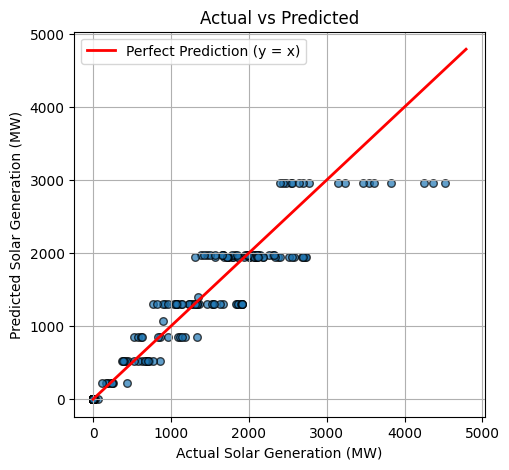

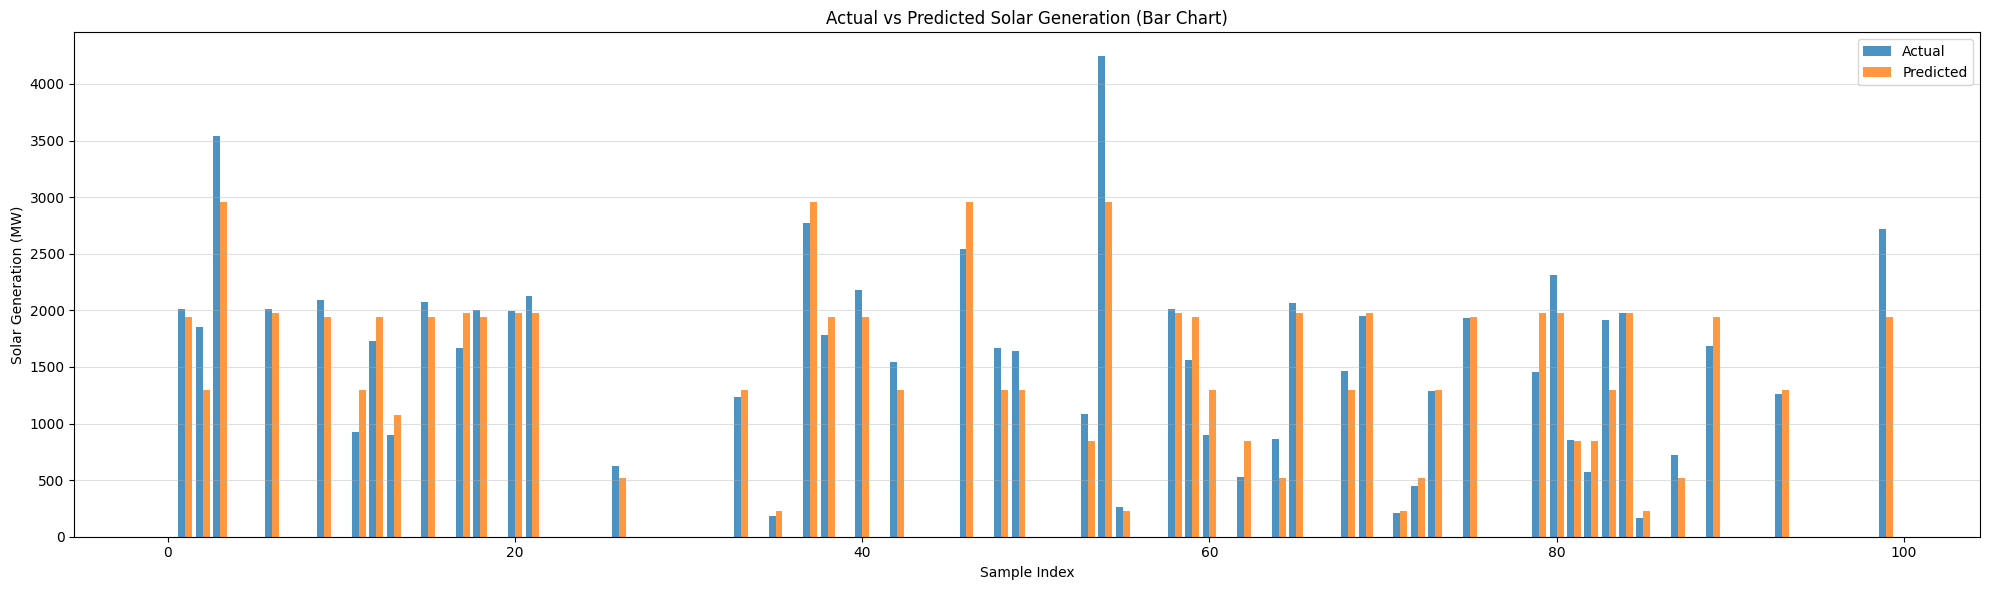

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ✅ Predictions already made
y_pred = final_model.predict(X_test_scaled)

# ✅ Calculate metrics (optional re-check)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Random Forest Test R2: {r2:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

# ✅ Compute residuals
residuals = y_test - y_pred

# ✅ Create figure with 3 subplots
plt.figure(figsize=(18, 5))

# -------------------------------------------
# 1️⃣ Actual vs Predicted (Zoomed-in for clarity)
# -------------------------------------------
plt.subplot(1, 3, 1)
plt.scatter(y_test[:300], y_pred[:300], alpha=0.7, edgecolor='k', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', lw=2, label='Perfect Prediction (y = x)')
plt.title("Actual vs Predicted")
plt.xlabel("Actual Solar Generation (MW)")
plt.ylabel("Predicted Solar Generation (MW)")
plt.legend()
plt.grid(True)


# Select first N points to plot
N = 100
actual = y_test[:N]
predicted = y_pred[:N]

# Create bar positions
x = np.arange(N)
width = 0.4

plt.figure(figsize=(20, 6))

# Bars for actual values
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)

# Bars for predicted values
plt.bar(x + width/2, predicted, width, label='Predicted', alpha=0.8)

plt.title("Actual vs Predicted Solar Generation (Bar Chart)")
plt.xlabel("Sample Index")
plt.ylabel("Solar Generation (MW)")
plt.legend()
plt.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

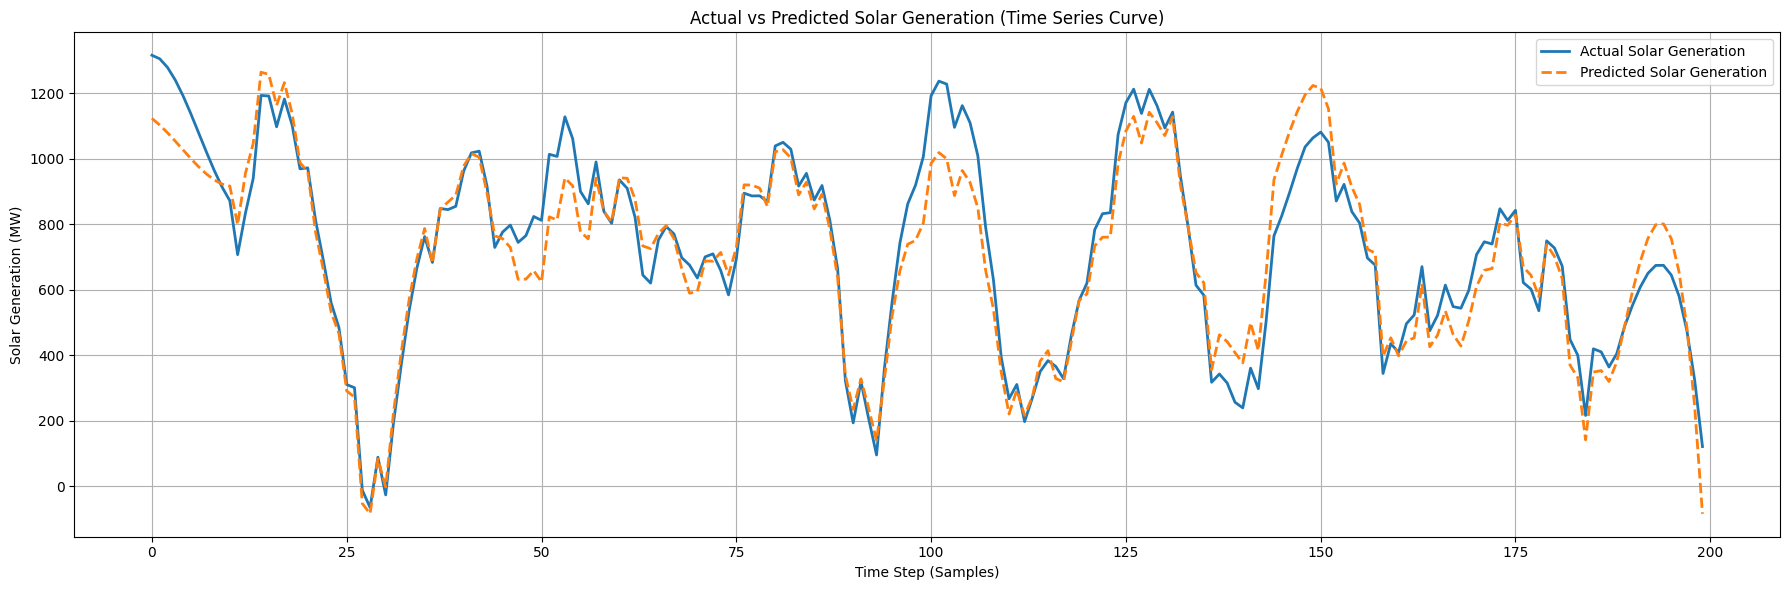

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter  # for smoothing curves

# Use first N points for clean visualization
N = 200   # You can increase if needed
actual = np.array(y_test[:N])
predicted = np.array(y_pred[:N])

# Optional smoothing (makes curve look realistic like solar profile)
actual_smooth = savgol_filter(actual, window_length=21, polyorder=3)
pred_smooth = savgol_filter(predicted, window_length=21, polyorder=3)

# Create time index for plotting
time = np.arange(N)

plt.figure(figsize=(18, 6))

# Plot actual curve
plt.plot(time, actual_smooth, label='Actual Solar Generation', linewidth=2)

# Plot predicted curve
plt.plot(time, pred_smooth, label='Predicted Solar Generation', linestyle='--', linewidth=2)

plt.title("Actual vs Predicted Solar Generation (Time Series Curve)")
plt.xlabel("Time Step (Samples)")
plt.ylabel("Solar Generation (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
